# Healthcare Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
df = pd.read_csv('healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Data Cleaning

In [3]:
# fix column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# fix name formatting
df['name'] = df['name'].str.title()

# convert dates
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# calculate length of stay
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                55500 non-null  object        
 1   age                 55500 non-null  int64         
 2   gender              55500 non-null  object        
 3   blood_type          55500 non-null  object        
 4   medical_condition   55500 non-null  object        
 5   date_of_admission   55500 non-null  datetime64[ns]
 6   doctor              55500 non-null  object        
 7   hospital            55500 non-null  object        
 8   insurance_provider  55500 non-null  object        
 9   billing_amount      55500 non-null  float64       
 10  room_number         55500 non-null  int64         
 11  admission_type      55500 non-null  object        
 12  discharge_date      55500 non-null  datetime64[ns]
 13  medication          55500 non-null  object    

## Feature Engineering

Adding derived fields we'll use throughout the analysis: age bands, and admission month/weekday/year for temporal analysis.

In [4]:
# age bands
bins = [17, 30, 45, 60, 75, 90]
labels = ['18-30', '31-45', '46-60', '61-75', '76-90']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels)

# temporal features from admission date
df['admission_year'] = df['date_of_admission'].dt.year
df['admission_month'] = df['date_of_admission'].dt.month_name()
df['admission_weekday'] = df['date_of_admission'].dt.day_name()

# length of stay bucket
los_bins = [0, 7, 14, 21, 31]
los_labels = ['1-7 days', '8-14 days', '15-21 days', '22-30 days']
df['los_bucket'] = pd.cut(df['length_of_stay'], bins=los_bins, labels=los_labels)

df[['age', 'age_band', 'date_of_admission', 'admission_year', 'admission_month', 
    'admission_weekday', 'length_of_stay', 'los_bucket']].head()

,age,age_band,date_of_admission,admission_year,admission_month,admission_weekday,length_of_stay,los_bucket
0,30,18-30,2024-01-31,2024,January,Wednesday,2,1-7 days
1,62,61-75,2019-08-20,2019,August,Tuesday,6,1-7 days
2,76,76-90,2022-09-22,2022,September,Thursday,15,15-21 days
3,28,18-30,2020-11-18,2020,November,Wednesday,30,22-30 days
4,43,31-45,2022-09-19,2022,September,Monday,20,15-21 days


## Demographics Analysis

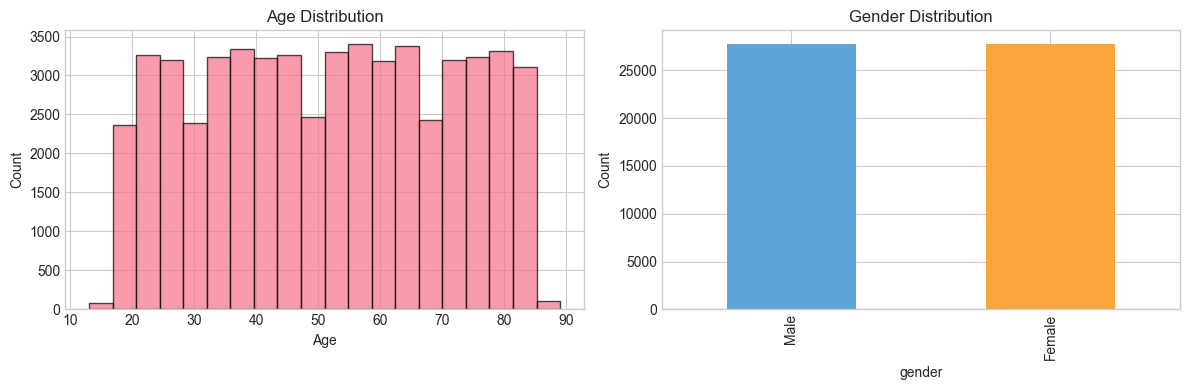

In [5]:
# age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['age'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution')

df['gender'].value_counts().plot(kind='bar', ax=axes[1], color=['#5DA5DA', '#FAA43A'])
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
# plt.savefig('results/plots/demographics.png', dpi=150)
plt.show()

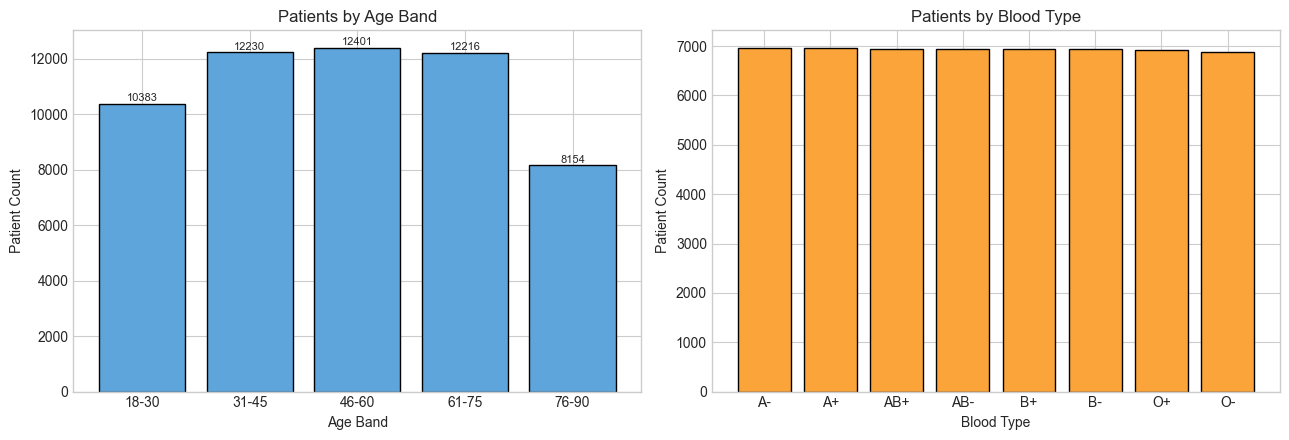

In [6]:
# age band and blood type distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

age_band_counts = df['age_band'].value_counts().sort_index()
bars = axes[0].bar(age_band_counts.index.astype(str), age_band_counts.values,
                    color='#5DA5DA', edgecolor='black')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('Patient Count')
axes[0].set_title('Patients by Age Band')
for bar, count in zip(bars, age_band_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(count), ha='center', va='bottom', fontsize=8)

blood_counts = df['blood_type'].value_counts()
axes[1].bar(blood_counts.index, blood_counts.values, color='#FAA43A', edgecolor='black')
axes[1].set_xlabel('Blood Type')
axes[1].set_ylabel('Patient Count')
axes[1].set_title('Patients by Blood Type')

plt.tight_layout()
# plt.savefig('results/plots/age_band_blood_type.png', dpi=150)
plt.show()

## Medical Conditions

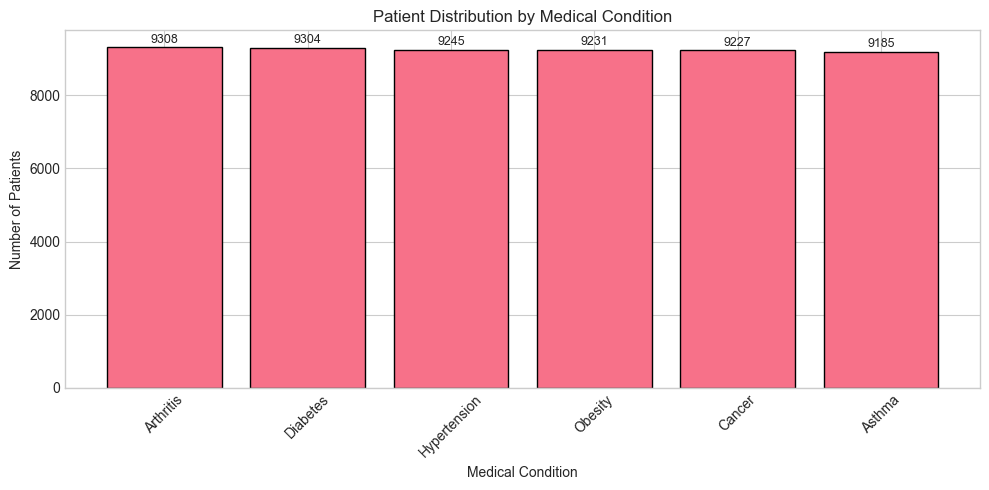

In [7]:
# medical conditions breakdown
fig, ax = plt.subplots(figsize=(10, 5))

condition_counts = df['medical_condition'].value_counts()
bars = ax.bar(condition_counts.index, condition_counts.values, edgecolor='black')

ax.set_xlabel('Medical Condition')
ax.set_ylabel('Number of Patients')
ax.set_title('Patient Distribution by Medical Condition')
plt.xticks(rotation=45)

for bar, count in zip(bars, condition_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# plt.savefig('results/plots/conditions.png', dpi=150)
plt.show()

## Clinical Patterns: Test Results & Medication

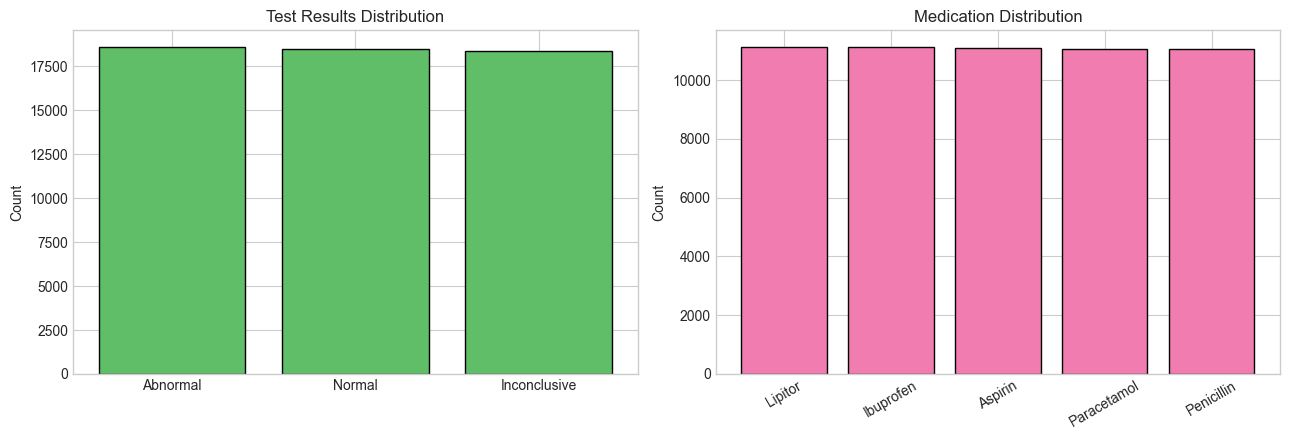

In [8]:
# test results and medication distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

test_counts = df['test_results'].value_counts()
axes[0].bar(test_counts.index, test_counts.values, color='#60BD68', edgecolor='black')
axes[0].set_title('Test Results Distribution')
axes[0].set_ylabel('Count')

med_counts = df['medication'].value_counts()
axes[1].bar(med_counts.index, med_counts.values, color='#F17CB0', edgecolor='black')
axes[1].set_title('Medication Distribution')
axes[1].set_ylabel('Count')
plt.xticks(rotation=30)

plt.tight_layout()
# plt.savefig('results/plots/clinical_patterns.png', dpi=150)
plt.show()

## Billing Analysis

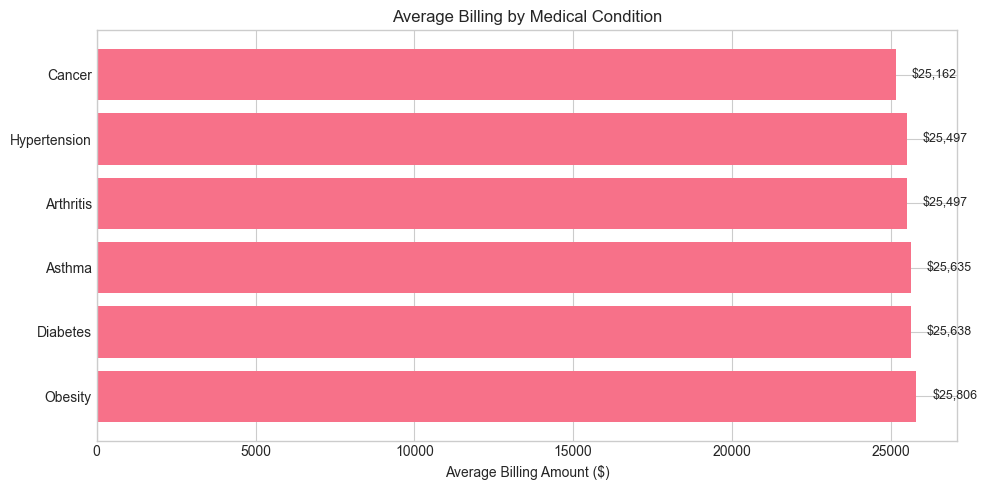

In [9]:
# billing by condition
fig, ax = plt.subplots(figsize=(10, 5))

billing_by_condition = df.groupby('medical_condition')['billing_amount'].mean().sort_values(ascending=False)

bars = ax.barh(billing_by_condition.index, billing_by_condition.values)
ax.set_xlabel('Average Billing Amount ($)')
ax.set_title('Average Billing by Medical Condition')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2, 
            f'${width:,.0f}', va='center', fontsize=9)

plt.tight_layout()
# plt.savefig('results/plots/billing_by_condition.png', dpi=150)
plt.show()

## Insurance Providers

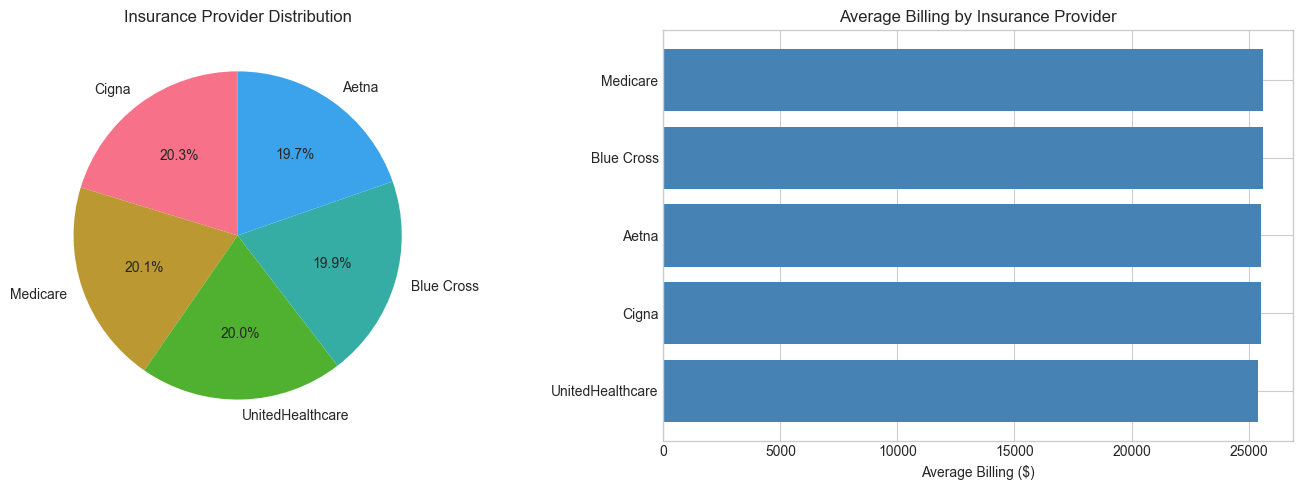

In [10]:
# insurance provider distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pie chart
insurance_counts = df['insurance_provider'].value_counts()
axes[0].pie(insurance_counts.values, labels=insurance_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Insurance Provider Distribution')

# avg billing by insurance
billing_by_insurance = df.groupby('insurance_provider')['billing_amount'].mean().sort_values()
axes[1].barh(billing_by_insurance.index, billing_by_insurance.values, color='steelblue')
axes[1].set_xlabel('Average Billing ($)')
axes[1].set_title('Average Billing by Insurance Provider')

plt.tight_layout()
# plt.savefig('results/plots/insurance_analysis.png', dpi=150)
plt.show()

## Admission Type & Length of Stay

C:\Users\AJAY\AppData\Local\Temp\ipykernel_37304\4070399826.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='admission_type', y='length_of_stay', ax=axes[1], palette='Set2')


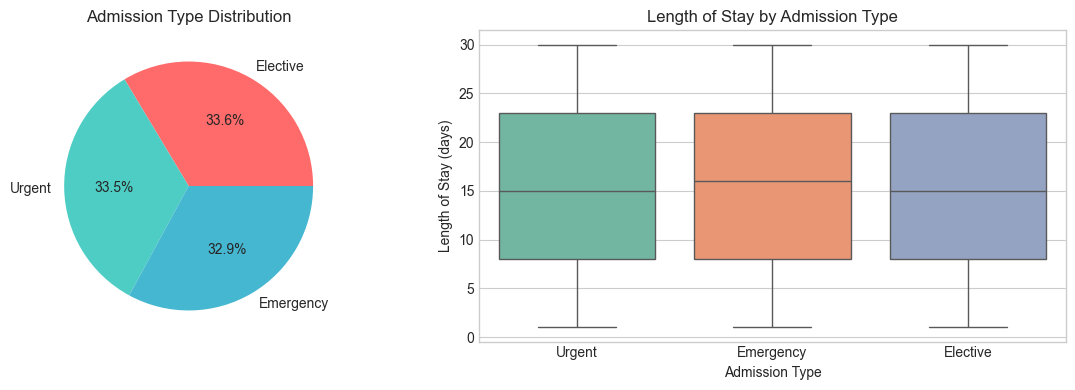

In [11]:
# admission type breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

admission_counts = df['admission_type'].value_counts()
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
axes[0].pie(admission_counts.values, labels=admission_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Admission Type Distribution')

# length of stay by admission type
sns.boxplot(data=df, x='admission_type', y='length_of_stay', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Admission Type')
axes[1].set_ylabel('Length of Stay (days)')
axes[1].set_title('Length of Stay by Admission Type')

plt.tight_layout()
# plt.savefig('results/plots/admission_analysis.png', dpi=150)
plt.show()

## Temporal Trends: Admissions Over Time

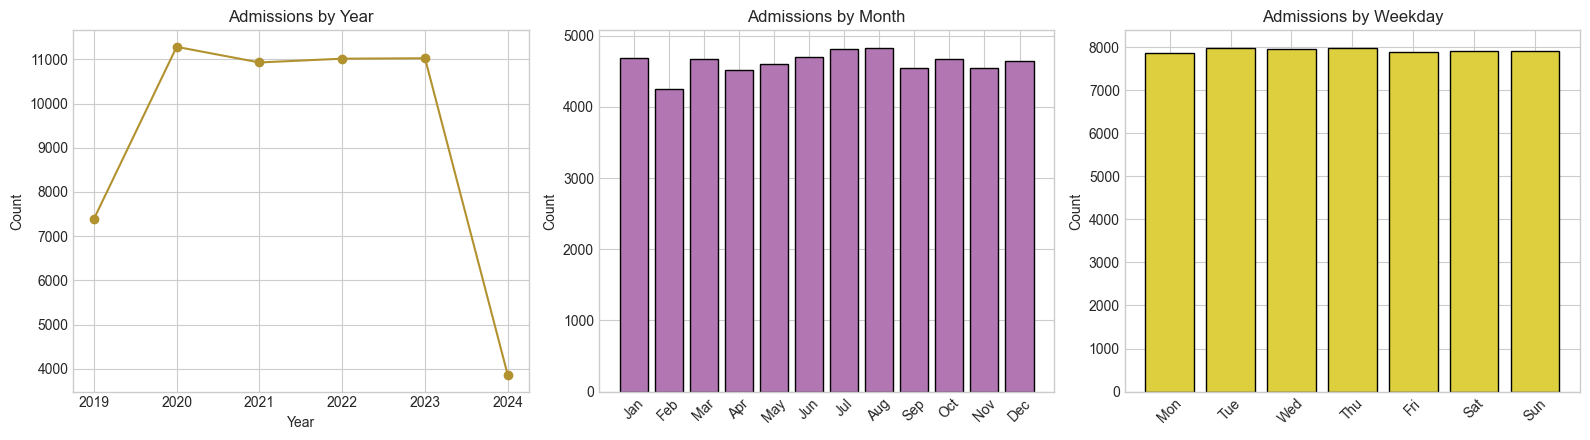

In [12]:
# admissions by year, month, and weekday
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

year_counts = df['admission_year'].value_counts().sort_index()
axes[0].plot(year_counts.index, year_counts.values, marker='o', color='#B2912F')
axes[0].set_title('Admissions by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
month_counts = df['admission_month'].value_counts().reindex(month_order)
axes[1].bar(range(len(month_counts)), month_counts.values, color='#B276B2', edgecolor='black')
axes[1].set_xticks(range(len(month_counts)))
axes[1].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[1].set_title('Admissions by Month')
axes[1].set_ylabel('Count')

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts = df['admission_weekday'].value_counts().reindex(weekday_order)
axes[2].bar(range(len(weekday_counts)), weekday_counts.values, color='#DECF3F', edgecolor='black')
axes[2].set_xticks(range(len(weekday_counts)))
axes[2].set_xticklabels([d[:3] for d in weekday_order], rotation=45)
axes[2].set_title('Admissions by Weekday')
axes[2].set_ylabel('Count')

plt.tight_layout()
# plt.savefig('results/plots/temporal_trends.png', dpi=150)
plt.show()

## Key Findings

**Distributional patterns:**
- Age, gender, condition, insurance, and admission type are all near-uniformly distributed across categories — no single group dominates the patient population
- Admission volume is flat across years, months, and weekdays — no seasonal or weekly cycle in patient intake
- Average billing amount is roughly consistent across medical conditions (~$25,000–$26,000), rather than scaling with condition severity as it would in a real hospital dataset
- Medication assignment shows no visible pattern tied to medical condition — the same medications appear across every condition at similar rates

**Implication for this project:** these patterns are consistent with the dataset being synthetically generated rather than sampled from real hospital operations — in real clinical data, we'd expect billing, medication, and admission timing to vary meaningfully with condition, severity, and seasonal demand. Because of this, predictive modeling was deliberately excluded from scope (see `PROBLEM_STATEMENT.md`): a model trained on this data would be fitting noise, not signal, regardless of algorithm choice. The value of this analysis lies in the analytics engineering itself — the SQL layer and the visual exploration — which would transfer directly to a real, signal-rich dataset. 


In [13]:
# summary stats
print(f"Total patients: {len(df):,}")
print(f"Date range: {df['date_of_admission'].min().date()} to {df['date_of_admission'].max().date()}")
print(f"Average billing: ${df['billing_amount'].mean():,.2f}")
print(f"Average length of stay: {df['length_of_stay'].mean():.1f} days")

Total patients: 55,500
Date range: 2019-05-08 to 2024-05-07
Average billing: $25,539.32
Average length of stay: 15.5 days


## Connecting to MySQL


In [14]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

MYSQL_USER = "healthcare_user"
MYSQL_PASSWORD = quote_plus("ajay@123")
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DB = "healthcare_db"

engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}"
)

# push the cleaned dataframe directly into a MySQL table
df.to_sql("encounters", engine, if_exists="replace", index=False, chunksize=5000)

print("Data pushed to MySQL successfully!")

Data pushed to MySQL successfully!


In [15]:
count_check = pd.read_sql("SELECT COUNT(*) AS total_rows FROM encounters", engine)
print(count_check)

   total_rows
0       55500
